In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [29]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [30]:
import os

print(os.listdir("archive"))


['.ipynb_checkpoints', 'casia', 'CASIA1', 'CASIA2']


In [31]:
import os
from PIL import Image

folder = "archive"

for filename in os.listdir(folder):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(folder, filename)
        img = Image.open(path)
        print("تمت قراءة:", filename, " - حجم:", img.size)





In [32]:
import os
print(os.getcwd())      # Display the current working directory
print(os.listdir())     # Show all files and subdirectories


C:\Users\HP\Downloads\image
['.ipynb_checkpoints', 'archive', 'casia_split', 'image detection.ipynb']


In [33]:
data_dir = os.path.join(os.getcwd(), "archive", "CASIA2")


In [34]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Use the correct directory path

data_dir = os.path.join(os.getcwd(), "archive", "CASIA2")

all_images = []
all_labels = []

# Loop through all folders inside CASIA2

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    
# Determine the class label from the folder name
    if folder.lower().startswith("au"):   # Authentic
        label = 1
    elif folder.lower().startswith("tp"): # Tampered
        label = 0
    else:
        continue  # Skip unknown or unrelated folders

    
    # Collect image paths

    for img in os.listdir(folder_path):
        all_images.append(os.path.join(folder_path, img))
        all_labels.append(label)

# Create the DataFrame

df = pd.DataFrame({
    'image_path': all_images,
    'label': all_labels
})

# Split into train and test sets

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print(train_df.head())


Train size: 10092
Test size: 2524
                                          image_path  label
0  C:\Users\HP\Downloads\image\archive\CASIA2\Tp\...      0
1  C:\Users\HP\Downloads\image\archive\CASIA2\Tp\...      0
2  C:\Users\HP\Downloads\image\archive\CASIA2\Au\...      1
3  C:\Users\HP\Downloads\image\archive\CASIA2\Au\...      1
4  C:\Users\HP\Downloads\image\archive\CASIA2\Tp\...      0


In [35]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Original image directory (make sure this path is correct)

data_dir = os.path.join(os.getcwd(), "archive", "CASIA2")
output_dir = os.path.join(os.getcwd(), "casia_split")


# Create new directories (train/val/test + real/fake)

for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:
        os.makedirs(os.path.join(output_dir, split, label), exist_ok=True)

# Collect images

real_images, fake_images = [], []

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    
    if folder.lower().startswith("au"):  # authentic
        real_images += [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    elif folder.lower().startswith("tp"):  # tampered
        fake_images += [os.path.join(folder_path, img) for img in os.listdir(folder_path)]

print("عدد الصور الأصلية:", len(real_images))
print("عدد الصور المزورة:", len(fake_images))

# Split the dataset (80% train, 10% val, 10% test)

def split_and_copy(images, label):
    train, test = train_test_split(images, test_size=0.2, random_state=42)
    val, test = train_test_split(test, test_size=0.5, random_state=42)

    for img_path in train:
        shutil.copy(img_path, os.path.join(output_dir, 'train', label))
    for img_path in val:
        shutil.copy(img_path, os.path.join(output_dir, 'val', label))
    for img_path in test:
        shutil.copy(img_path, os.path.join(output_dir, 'test', label))

split_and_copy(real_images, 'real')
split_and_copy(fake_images, 'fake')

print(" تم تجهيز البيانات في:", output_dir)


عدد الصور الأصلية: 7492
عدد الصور المزورة: 5124
✅ تم تجهيز البيانات في: C:\Users\HP\Downloads\image\casia_split


In [37]:
import os
print(os.getcwd())
print(os.listdir())


C:\Users\HP\Downloads\image
['.ipynb_checkpoints', 'archive', 'casia_split', 'image detection.ipynb']


In [38]:
train_generator = train_datagen.flow_from_directory(
    'casia_split/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    'casia_split/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    'casia_split/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 10090 images belonging to 2 classes.
Found 1261 images belonging to 2 classes.
Found 1263 images belonging to 2 classes.


In [ ]:
import os
print(os.listdir("/kaggle/working/casia_split"))
print("train:", os.listdir("/kaggle/working/casia_split/train"))
print("val:", os.listdir("/kaggle/working/casia_split/val"))
print("test:", os.listdir("/kaggle/working/casia_split/test"))


In [41]:
import os

base_dir = "casia_split"  # Jupyter's current working directory since the notebook is inside a folder


print(os.listdir(base_dir))
print("train:", os.listdir(os.path.join(base_dir, "train")))
print("val:", os.listdir(os.path.join(base_dir, "val")))
print("test:", os.listdir(os.path.join(base_dir, "test")))


['test', 'train', 'val']
train: ['fake', 'real']
val: ['fake', 'real']
test: ['fake', 'real']


In [39]:
# Print the assigned class labels
print("Class indices:", train_generator.class_indices)

Class indices: {'fake': 0, 'real': 1}


In [40]:
# Fetch a batch of images and labels
images, labels = next(train_generator)

# Print the first 10 labels
print("First 10 labels in batch:", labels[:10])

First 10 labels in batch: [0. 1. 0. 0. 1. 0. 0. 0. 1. 0.]


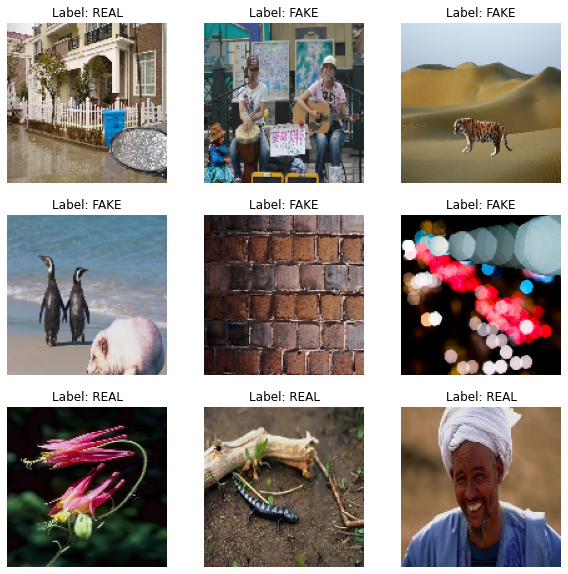

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Fetch a batch of images and labels
images, labels = next(train_generator)

# Define class names
class_names = {0: 'FAKE', 1: 'REAL'}

# Plot first 9 images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])  # Display the image
    plt.title(f"Label: {class_names[int(labels[i])]}")
    plt.axis('off')
plt.show()

In [44]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Do not load pretrained weights from the internet
base_model = ResNet50(weights=None, include_top=False, input_shape=(128, 128, 3))

base_model.trainable = True  # Train the model entirely from scratch (no pretrained initialization)



model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=12)


Epoch 1/12
316/316 [==============================] - 3684s 12s/step - loss: 0.7346 - accuracy: 0.5841 - val_loss: 0.7705 - val_accuracy: 0.5932
Epoch 2/12
316/316 [==============================] - 3353s 11s/step - loss: 0.6567 - accuracy: 0.6242 - val_loss: 0.6649 - val_accuracy: 0.6257
Epoch 3/12
316/316 [==============================] - 2365s 7s/step - loss: 0.6326 - accuracy: 0.6438 - val_loss: 0.6765 - val_accuracy: 0.5948
Epoch 4/12
316/316 [==============================] - 1231s 4s/step - loss: 0.6103 - accuracy: 0.6609 - val_loss: 0.6364 - val_accuracy: 0.6257
Epoch 5/12
316/316 [==============================] - 1232s 4s/step - loss: 0.6015 - accuracy: 0.6679 - val_loss: 0.6181 - val_accuracy: 0.6534
Epoch 6/12
316/316 [==============================] - 1221s 4s/step - loss: 0.5831 - accuracy: 0.6866 - val_loss: 0.6283 - val_accuracy: 0.6487
Epoch 7/12
316/316 [==============================] - 1158s 4s/step - loss: 0.5660 - accuracy: 0.7024 - val_loss: 0.6642 - val_accurac

In [47]:
# Print the total number of layers in ResNet50
print("Total Layers in ResNet50:", len(base_model.layers))

Total Layers in ResNet50: 175


In [51]:
print(model.name)


sequential_1


In [57]:
model.name

'sequential_1'

In [59]:
import json
import os

# 1. Save the full model using its name
model.save(f"{model.name}_full_model.h5")

# 2. Save the training history using the same name
with open(f"{model.name}_history.json", "w") as f:
    json.dump(history.history, f)

# 3. Verify that the files were saved correctly
print(" تم الحفظ:")
print(os.listdir("."))


✅ تم الحفظ:
['.ipynb_checkpoints', 'archive', 'casia_split', 'image detection.ipynb', 'resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5', 'sequential_1_full_model.h5', 'sequential_1_history.json', 'Untitled.ipynb']


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import json
import os

# Load the previously saved model
model = load_model("resnet50_binary_classifier_full_model.h5")  # Change the filename if yours is different


# Configure layers for training (extract the ResNet50 base model)
base_model = model.layers[0]    # ResNet50 base
base_model.trainable = True     # Make the ResNet50 base model trainable

# Freeze the first 100 layers of ResNet50
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile the model with a small learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Continue training (Fine-tuning)
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

# Save the fine-tuned model using its name
model.save(f"{model.name}_finetuned.h5")

# Save the fine-tuning training history using the same name
with open(f"{model.name}_finetuned_history.json", "w") as f:
    json.dump(history_finetune.history, f)

print(" تم الحفظ:")
print(os.listdir("."))


In [60]:
import json
import os

# Save the full model (architecture + weights + training configuration)
model.save(f"{model.name}_full_model.h5")

# Save the architecture only (optional)
with open(f"{model.name}_architecture.json", "w") as json_file:
    json_file.write(model.to_json())

# Verify that the files were saved in the same Notebook directory
print(" الملفات المحفوظة:")
print(os.listdir("."))


✅ الملفات المحفوظة:
['.ipynb_checkpoints', 'archive', 'casia_split', 'image detection.ipynb', 'resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5', 'sequential_1_architecture.json', 'sequential_1_full_model.h5', 'sequential_1_history.json', 'Untitled.ipynb']
